Loading and preparing data...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

Pipeline and FOCUSED parameter grid are ready.
--- Starting Refined Hyperparameter Search (GridSearchCV v3) ---
Fitting 3 folds for each of 72 candidates, totalling 216 fits

--- Grid Search Complete (v3) ---
Total search time: 3397.76 seconds

Best F1-Macro Score (from cross-validation):
0.4276

Best Hyperparameters Found:
{'svm__C': 1.0, 'tfidf__max_df': 0.9, 'tfidf__max_features': 5000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}

--- Evaluating Best Model on Unseen Test Set ---

Classification Report (Per-Class):
                 precision    recall  f1-score   support

     Ambivalent       0.72      0.56      0.63       206
Clear Non-Reply       0.31      0.43      0.36        23
    Clear Reply       0.27      0.39      0.32        79

       accuracy                           0.51       308
      macro avg       0.43      0.46      0.44       308
   weighted avg       0.57      0.51      0.53       308

Confusion Matrix:


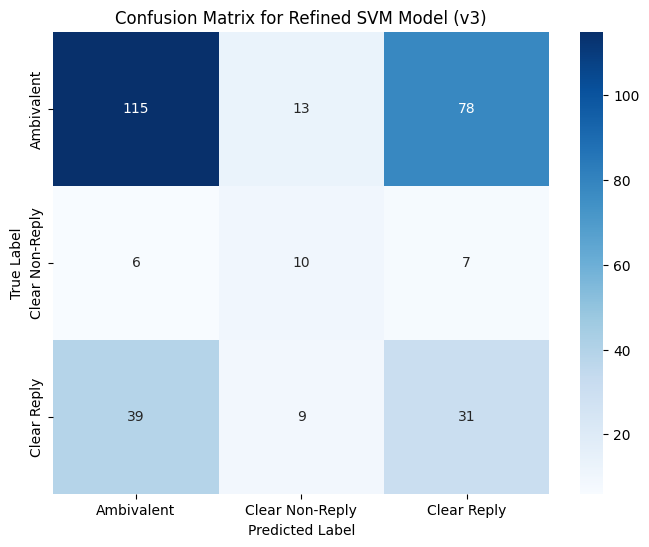

In [1]:
import pandas as pd
import numpy as np
import time
from datasets import load_dataset
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# --- Imports from imblearn ---
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Suppress warnings
warnings.filterwarnings('ignore')

# --- Load and Prepare Data (Same as before) ---
print("Loading and preparing data...")
dataset = load_dataset("ailsntua/QEvasion")
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

train_df['text_input'] = train_df['question'] + " " + train_df['interview_answer']
test_df['text_input'] = test_df['question'] + " " + test_df['interview_answer']

X_train = train_df['text_input']
y_train = train_df['clarity_label']
X_test = test_df['text_input']
y_test = test_df['clarity_label']

# --- Define the winning pipeline structure ---
# We will ONLY use this structure, based on v2 results
focused_pipeline = ImbPipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('svm', SVC(random_state=42, kernel='linear', class_weight=None)) # Based on v2 winner
])


# --- New, Focused Parameter Grid ---
# We are now drilling down into the TF-IDF and C parameters
param_grid = [
    {
        'tfidf__ngram_range': [(1, 1), (1, 2)],          # Test unigrams-only vs. unigrams+bigrams
        'tfidf__max_df': [0.9, 1.0],                   # Ignore words in >90% of docs, or don't (1.0)
        'tfidf__min_df': [2, 3, 5],                    # Previous winner was 3
        'tfidf__max_features': [5000, 7000],           # Previous winner was 5000
        'svm__C': [0.1, 0.5, 1.0]                      # Search around previous winner 0.5
    }
]
# Total fits: 2 * 2 * 3 * 2 * 3 = 72 combinations
# This is (72 * 3) = 216 fits. Should be much faster than v2 without the poly kernel.

print("Pipeline and FOCUSED parameter grid are ready.")
print("--- Starting Refined Hyperparameter Search (GridSearchCV v3) ---")

# 1. Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=focused_pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# 2. Start the timer and run the search
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()

# 3. Print the results
training_time = end_time - start_time
print(f"\n--- Grid Search Complete (v3) ---")
print(f"Total search time: {training_time:.2f} seconds")

print("\nBest F1-Macro Score (from cross-validation):")
print(f"{grid_search.best_score_:.4f}")

print("\nBest Hyperparameters Found:")
print(grid_search.best_params_)

print("\n--- Evaluating Best Model on Unseen Test Set ---")
y_pred = grid_search.predict(X_test)

# --- Display Results ---
print("\nClassification Report (Per-Class):")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
classes = grid_search.best_estimator_.classes_
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.title('Confusion Matrix for Refined SVM Model (v3)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()